In [1]:
from helperfunctions import helper as hfn
from helperfunctions import training_lib as tl
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from helperfunctions import controlled_env as ce
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, MaxNLocator
from typing import Dict
import pandas as pd
import numpy as np
import torch.nn as nn
from glob import glob
import os
from pathlib import Path
import pandas as pd
#%matplotlib widget

In [2]:
cfg_dummy = hfn.TrainConfig(config_name="further_content_part1_1", part1=True)

{
  "config_name": "further_content_part1_1",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2019-11-06 18:40:00",
  "test_end_time": "2020-04-01 04:00:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
   

In [3]:
ae_list = tl.get_model_results(src=ic.PATH_TO_BEST_MODEL_DIR, best_n=1)

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\torch\amp\grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


name:activation__Seed_32_uid_8c8d353bea.pth
 best val error:0.17704901592204464
 best train error:0.009280807258664099
 model params:5425



In [4]:
ae1,_,ckpt1,_,_ = ae_list[0]

In [5]:
try:
    df_val_eval = pd.read_csv(ic.PATH_PART1_VAL_LOSS_DIR / "df_val_eval.csv")

except FileNotFoundError:
    _, val_loader , test_loader = hfn.build_dataloaders(
    train_csv_dir=ic.PATH_PC_FILTERING,
    val_csv_dir= ic.PATH_IMPUTED,
    test_csv_dir=ic.PATH_PART1_VAL_SET_INJ_DIR,
    cfg=cfg_dummy,
)
    df_val_eval = tl.eval_model(model=ae1,
                                data_loader=val_loader,
                                device=ckpt1['train_config'].device,
                                loss_fn=nn.MSELoss(reduction="none")
                                )

    df_val_eval.to_csv(ic.PATH_PART1_VAL_LOSS_DIR / "df_val_eval.csv", index=False)



In [6]:
try:
    df_test_eval = pd.read_csv(ic.PATH_PART1_TEST_LOSS_DIR/ "df_inj_eval.csv")

except FileNotFoundError:

    df_test_eval = tl.eval_model(model=ae1,
                                data_loader=test_loader,
                                device=ckpt1['train_config'].device,
                                loss_fn=nn.MSELoss(reduction="none")
                                )

    df_test_eval.to_csv(ic.PATH_PART1_TEST_LOSS_DIR/ "df_inj_eval.csv", index=False)

In [7]:
display(df_test_eval.head())

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),...,RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1573065600000000001,2019-11-06 18:40:00,1,0.189898,0.018049,1.153168e-01,0.050099,0.041363,0.176103,0.322575,...,0.427687,0.330300,0.323546,0.315487,0.528006,0.047788,0.044411,0.013733,0.007373,0.000140
1,1573065600000000002,2019-11-06 18:40:00,2,0.009512,0.002488,1.442957e-01,0.000263,0.006323,0.000233,0.001487,...,0.000985,0.000053,0.004059,0.029579,0.014336,0.009078,0.016176,0.004375,0.016720,0.000009
2,1573065600000000004,2019-11-06 18:40:00,4,0.001421,0.000375,6.287894e-08,0.001531,0.001773,0.000108,0.000137,...,0.000402,0.009852,0.000326,0.009064,0.002026,0.000622,0.002270,0.000033,0.000012,0.000016
3,1573065600000000005,2019-11-06 18:40:00,5,0.159350,0.042883,2.396303e-02,0.321126,0.501948,0.142605,0.269832,...,0.334198,0.363769,0.363716,0.193068,0.585714,0.073496,0.002403,0.071901,0.001334,0.001654
4,1573065600000000006,2019-11-06 18:40:00,6,0.006012,0.005634,5.360473e-02,0.002404,0.002161,0.000992,0.010291,...,0.000318,0.005435,0.000647,0.000051,0.001161,0.005126,0.000468,0.000958,0.007484,0.000006


In [8]:
fp_best_k = ic.PATH_PART1_K_AGG_METRICS_DIR / "best_ks_per_wt.csv"

threshold_df = pd.read_csv(fp_best_k)
display(threshold_df.head(10))
theta = threshold_df["threshold"].iloc[0]
print(theta)
# theta = float(threshold_df.query(f"{ic.WT_ID} ==7 and {ic.SIGNAL_COL} == 'Mean'")["threshold"].iloc[0])

,WT_ID,k,mu,sigma,threshold,tp,fn,fp,precision,recall,f1,FAR_per_day,latency_mean
0,1,1.0,0.013096,0.029094,0.04219,7.0,1.0,236.0,0.028807,0.875,0.055777,1.594595,111.714286


0.0421903147970119


In [9]:
cat_win_path = ic.PATH_PART1_K_AGG_METRICS_DIR / "anom_windows.csv"

cat_windows = pd.read_csv(cat_win_path)

cat_windows = cat_windows.sort_values(by=ce.AnomOverviewKeys.TS_START)

spans_all = list(zip(pd.to_datetime(cat_windows[ce.AnomOverviewKeys.TS_START]),
                     pd.to_datetime(cat_windows[ce.AnomOverviewKeys.TS_END])))




for i in spans_all:
    print(i)



(Timestamp('2019-12-15 00:00:00'), Timestamp('2019-12-22 00:00:00'))
(Timestamp('2019-12-24 00:00:00'), Timestamp('2019-12-31 00:00:00'))
(Timestamp('2020-01-09 00:00:00'), Timestamp('2020-01-09 00:00:00'))
(Timestamp('2020-01-18 00:00:00'), Timestamp('2020-01-18 00:00:00'))
(Timestamp('2020-01-20 00:00:00'), Timestamp('2020-01-27 00:00:00'))
(Timestamp('2020-01-29 00:00:00'), Timestamp('2020-02-05 00:00:00'))
(Timestamp('2020-02-07 00:00:00'), Timestamp('2020-02-14 00:00:00'))
(Timestamp('2020-02-16 00:00:00'), Timestamp('2020-02-23 00:00:00'))


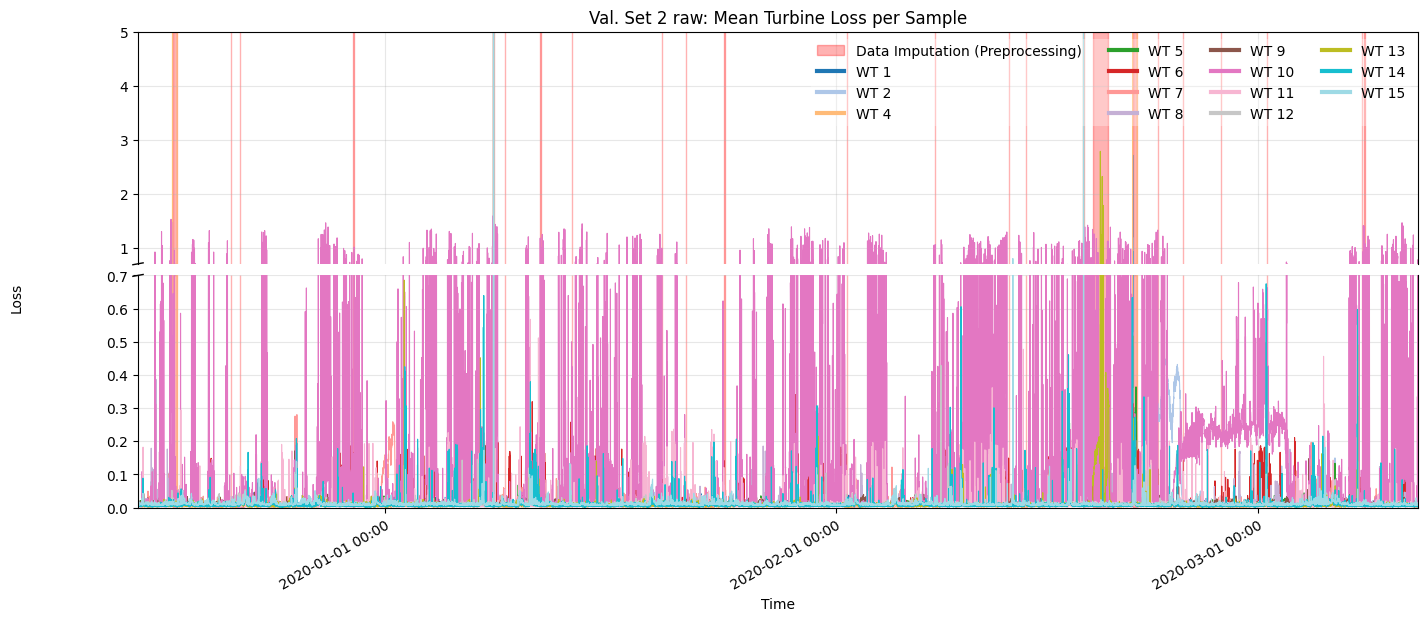

In [10]:
pp.print_loss(df_val_eval,
              dpi=500,
              y_limits=((0,0.7),(0.7,5)),
              upper_ylim_to_max=False,
              title="Val. Set 2 raw: Mean Turbine Loss per Sample",
              wt_id= None,
              ts_range=(ic.START_ANOM, '2020-03-12 00:00:00'),
              anomaly_spans=None,
              )

### Summary of Mean, Std, Median per WT

In [11]:
def summarize_re_means_by_wt(df_eval: pd.DataFrame) -> pd.DataFrame:
    grouped = (
        df_eval
        .groupby(ic.WT_ID, as_index=False)[ic.MEAN_LOSS_PER_SAMPLE]
        .agg(mean_re = "mean",
             std_re="std",
             median_re="median",
             count="count")
    )
    return grouped.sort_values(by=ic.WT_ID).reset_index(drop=True)

def get_re_means_per_wt(df_eval:pd.DataFrame) -> Dict[int, np.ndarray]:
    ret_dict: Dict[int, np.ndarray]= {}
    for wt_id, gr in df_eval.groupby(ic.WT_ID):
        vals = gr[ic.MEAN_LOSS_PER_SAMPLE].to_numpy(dtype=float, copy=True)
        ret_dict[int(wt_id)] = vals
        
    return ret_dict

In [12]:
summ_per_wt = summarize_re_means_by_wt(df_val_eval)
display(summ_per_wt)

,WT_ID,mean_re,std_re,median_re,count
0,1,0.013096,0.029095,0.009238,21081
1,2,0.018346,0.040387,0.011859,21081
2,4,0.386570,5.383538,0.004255,21081
3,5,0.013105,0.025393,0.008819,21081
4,6,0.017231,0.036359,0.006793,21081
5,7,2.499581,8.240332,0.007677,21081
6,8,0.015042,0.016539,0.012047,21081
7,9,0.013259,0.014185,0.010681,21081
8,10,0.115642,0.235497,0.012108,21081
9,11,0.012634,0.039727,0.004982,21081


In [13]:
print(summ_per_wt["median_re"].mean())

0.008497045009529965


In [14]:
RE_per_wt = get_re_means_per_wt(df_val_eval)

wt_list = [1,2,4,5,6,7,8,9,10,11,12,13,14,15]

# for wt in wt_list:
#     wt_val = RE_per_wt[wt]
#     fig, ax = plt.subplots()
#     bins = np.arange(0.0, 0.25 + 0.0001, 0.0001)
#     ax.hist(wt_val, bins=bins)
    
#     ax.set_title(f"Distribution of RE-Means for WT {wt}")
#     ax.set_xlabel(ic.MEAN_LOSS_PER_SAMPLE)
#     ax.set_ylabel("count")
#     ax.xaxis.set_major_locator(MultipleLocator(0.0001))
#     ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
#     plt.show()


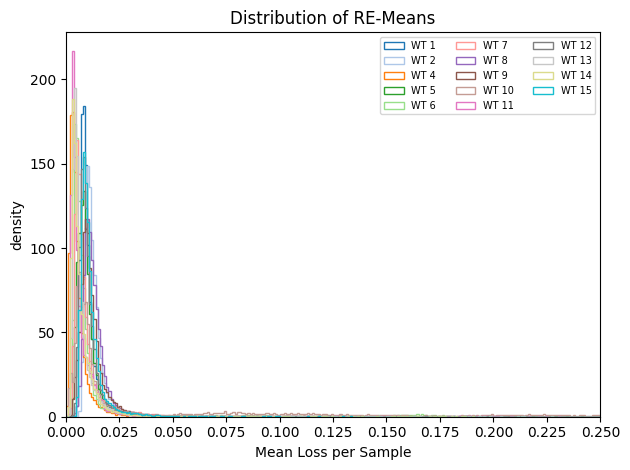

In [15]:
bins = np.arange(0.0, 0.25 + 0.001, 0.001)
data_list = [RE_per_wt[wt] for wt in wt_list]
cmap = plt.colormaps["tab20"]

fig, ax = plt.subplots()
for i,wt in enumerate(wt_list):
    wt_val = RE_per_wt[wt]
    color = cmap(i /len(wt_list))
    ax.hist(wt_val,
            bins=bins,
            histtype="step",
            density=True,
            label=f"WT {wt}",
            color=color)

ax.set_title(f"Distribution of RE-Means")
ax.set_xlabel(ic.MEAN_LOSS_PER_SAMPLE)
ax.set_ylabel("density")
ax.set_xlim(0.0, 0.25)
#ax.set_yscale("log")
ax.xaxis.set_major_locator(MultipleLocator(0.01))
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))

ax.legend(ncol=3, fontsize=7)

fig.tight_layout()
plt.show()


In [16]:
anom_span_labels = [
    "Add. Offset 1",
    "Add. Offset 2",
    "Point Anom. 1",
    "Point Anom. 2",
    "Mult. Drift",
    "Corr. Anom. 1",
    "Corr. Anom. 2",
    "Corr. Anom. 3"
]

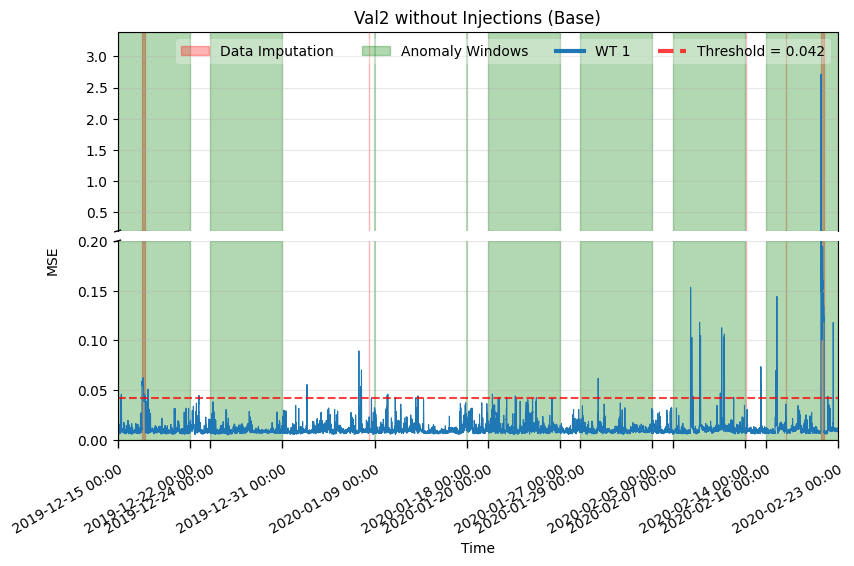

In [17]:
pp.print_loss(df_val_eval,
              dpi=500,
              y_limits=((0,0.2),(0.2,0.4)),
              title=f"Val2 without Injections (Base)",
              impute_label="Data Imputation",
              y_label="MSE",
              save_filename=Path(ic.PATH_PRINTS) / "part1_mean_raw.png",
              wt_id=[1],
              anom_span_label="Anomaly Windows",
              ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'),
              anomaly_spans=spans_all,
              mark_threshold=theta,
              #anom_span_labels=anom_span_labels,
              figsize=(9,6),
              show_mean=False
              )


In [18]:
print("threshold value:", theta)

threshold value: 0.0421903147970119


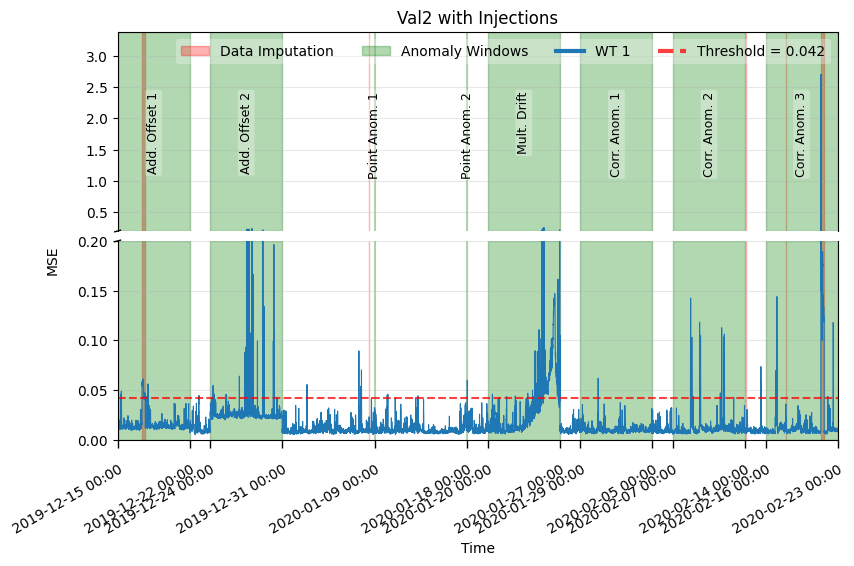

In [19]:

pp.print_loss(df_test_eval,
              dpi=500,
              y_limits=((0,0.2),(0.2,40)),
              title="Val2 with Injections",
              save_filename=Path(ic.PATH_PRINTS) / "part1_mean_injected.png",
              wt_id= [1],
            #   ts_range=("2018-08-01 00:00:00","2018-10-28 00:00:00"),
              ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'),
              anomaly_spans=spans_all,
              line_width=0.8,
              mark_threshold=theta,
              show_mean=False,
              anom_span_labels=anom_span_labels,
              figsize=(9,6),
              impute_label="Data Imputation",
              anom_span_label="Anomaly Windows",
              y_label="MSE",
              )

In [20]:
ratio_mse, mu_mse, sigma_mse = ce.Report.create_mu_sigma_ratio_table(
    df_base_eval=df_val_eval,
    df_inj_eval=df_test_eval,
    signals=[ic.MEAN_LOSS_PER_SAMPLE],
    anom_spans=spans_all,
    anom_cats=anom_span_labels,
    wt_id=1,
)

In [21]:
display(ratio_mse)
display(mu_mse)
display(sigma_mse)

ltx_r = ratio_mse.to_latex(index=False, escape=False,float_format="%.2f")

with open(ic.PATH_PRINTS /"p1_mu_sigma_ratios_MSE.tex", "w", encoding="utf-8") as f:
    f.write(ltx_r)

ltx_s = sigma_mse.to_latex(index=False, escape=False,float_format="%.3f")

with open(ic.PATH_PRINTS /"p1_sigmas_b_MSE.tex", "w", encoding="utf-8") as f:
    f.write(ltx_s)

ltx_m = mu_mse.to_latex(index=False, escape=False,float_format="%.3f")

with open(ic.PATH_PRINTS /"p1_mus_b_MSE.tex", "w", encoding="utf-8") as f:
    f.write(ltx_m)

,Signal,1. RCM,2. RCM,3. RCM,4. RCM,5. RCM,6. RCM,7. RCM,8. RCM,1. RCSD,2. RCSD,3. RCSD,4. RCSD,5. RCSD,6. RCSD,7. RCSD,8. RCSD
0,MSE,1.387,3.105,2.421,4.23,2.76,1.028,1.0,1.003,0.932,7.324,0.0,0.0,5.17,1.02,0.991,1.004


,Signal,1. $\hat\mu_{base}$,2. $\hat\mu_{base}$,3. $\hat\mu_{base}$,4. $\hat\mu_{base}$,5. $\hat\mu_{base}$,6. $\hat\mu_{base}$,7. $\hat\mu_{base}$,8. $\hat\mu_{base}$
0,MSE,0.012,0.009,0.007,0.014,0.012,0.01,0.012,0.021


,Signal,1. $\hat\sigma_{base}$,2. $\hat\sigma_{base}$,3. $\hat\sigma_{base}$,4. $\hat\sigma_{base}$,5. $\hat\sigma_{base}$,6. $\hat\sigma_{base}$,7. $\hat\sigma_{base}$,8. $\hat\sigma_{base}$
0,MSE,0.01,0.003,0.0,0.0,0.007,0.004,0.012,0.094


In [22]:
def row_to_tex(df:pd.DataFrame,path:Path=Path(ic.PATH_PRINTS),fn:str="dummy"):
    cols = df.columns.tolist()
    if len(df[cols[1:]].iloc[0]) > 8:
        for i in range(len(df)):

            line = ", ".join(map(str, df[cols[1:9]].iloc[i].to_list()))
            line2 =  ", ".join(map(str, df[cols[9:]].iloc[i].to_list()))
            line = fr"$\frac{{\hat\mu_{{anom}}}}{{\hat\mu_{{base}}}}$: " + line
            line = line + fr"\\" +fr"$\frac{{\hat\sigma_{{anom}}}}{{\hat\sigma_{{base}}}}$: " + line2
            ptf = (path/f"{fn}_{df.iloc[i][0]}_{i+1}.tex")
            ptf.write_text(line, encoding="utf-8")
            #print(str(ptf))
    else:
        for i in range(len(df)):
            line = ", ".join(map(str, df[cols[1:]].iloc[i].to_list()))
            if "mu" in cols[1]:
                line = fr"$\hat\mu_{{base}}$: " + line
            else:
                line = fr"$\hat\sigma_{{base}}$: " + line
            ptf = (path/f"{fn}_{df.iloc[i][0]}_{i+1}.tex")
            ptf.write_text(line, encoding="utf-8")

row_to_tex(ratio_mse,fn="p1_mse_ratios")
row_to_tex(mu_mse,fn="p1_mse_mus")
row_to_tex(sigma_mse,fn="p1_mse_sigmas")


C:\Users\admin\AppData\Local\Temp\ipykernel_22936\2636796566.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ptf = (path/f"{fn}_{df.iloc[i][0]}_{i+1}.tex")
C:\Users\admin\AppData\Local\Temp\ipykernel_22936\2636796566.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ptf = (path/f"{fn}_{df.iloc[i][0]}_{i+1}.tex")
C:\Users\admin\AppData\Local\Temp\ipykernel_22936\2636796566.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

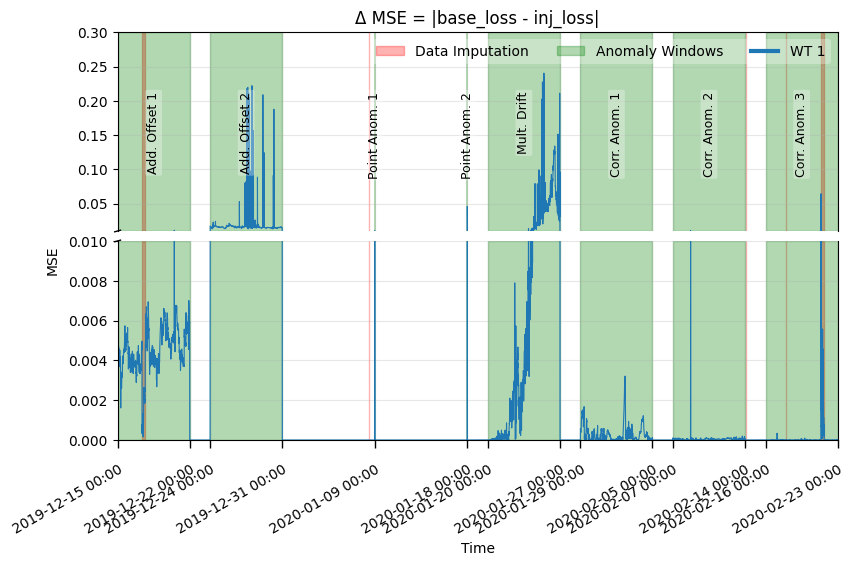

In [23]:
wt = 1
df_diff = ce.Eval_Anom.build_diff_df_for_signal(wt, 
                                                signal=ic.MEAN_LOSS_PER_SAMPLE, 
                                                wt_df_raw= df_val_eval,
                                                wt_df_inj= df_test_eval,
                                                ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'))

pp.print_loss(
            df_diff, 
            dpi=500,
            save_filename= Path(ic.PATH_PRINTS) / "part1_delta_mean.png",
            y_limits=((0,0.01),(0.01,0.25)), 
            wt_id=[1],
            title=f"Δ MSE = |base_loss - inj_loss|" ,
            values=ic.MEAN_LOSS_PER_SAMPLE,
            ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'),
            anomaly_spans=spans_all,
            anom_span_labels=anom_span_labels,
            figsize=(9,6),
            show_mean=False,
            impute_label="Data Imputation",
            anom_span_label="Anomaly Windows",
            y_label="MSE",
            )

In [24]:
sigs = ["Rotor bearing temp (°C)","Stator temperature 1 (°C)","Transformer cell temperature (°C)","Generator bearing front temperature (°C)","Generator bearing rear temperature (°C)"]

In [25]:
descr_stats = ce.Eval_Anom.descr_stats_raw_inj(
    df_raw = df_val_eval,
    df_inj = df_test_eval,
    anom_spans=spans_all,
    anom_span_labels=anom_span_labels,
    wt_id=1,
    theta = theta,
)
# fmt = {
#     "BL Coverage": lambda x: f"{x:.2f}", 
#     "Anom. Coverage": lambda x: f"{x:.2f}", 
#     "Anom. Latency": lambda x: f"{x:.2f}", 
#     "BL Latency": lambda x: f"{x:.2f}", 
#     "Latency": lambda x: np.NaN if pd.isna(x) else f"{int(x)}", 
# }
keep = ["Anomaly Type","BL Latency","Anom. Latency","BL Coverage","Anom. Coverage","Samples"]
_sigs_col = [sigs[0],sigs[0],sigs[1],sigs[1],sigs[2],sigs[3],sigs[3],sigs[3]]
_sigs = pd.Series(_sigs_col)
descr_stats["Signal"] = _sigs
keep = ["Signal"]+keep
display(keep)
descr_stats = descr_stats[keep]
descr_stats.rename(columns={"Anomaly Type": "Anomaly Category"}, inplace=True)
display(descr_stats)

ltx = descr_stats.to_latex(index=False, float_format="%.2f", escape=False)
with open(ic.PATH_PRINTS/"descr_stats_p1.tex", "w", encoding="utf-8") as f:
    f.write(ltx)

['Signal',
 'Anomaly Type',
 'BL Latency',
 'Anom. Latency',
 'BL Coverage',
 'Anom. Coverage',
 'Samples']

,Signal,Anomaly Category,BL Latency,Anom. Latency,BL Coverage,Anom. Coverage,Samples
0,Rotor bearing temp (°C),Add. Offset 1,42.0,42.0,0.038690,0.049603,1008
1,Rotor bearing temp (°C),Add. Offset 2,NaN,38.0,0.000000,0.040675,1008
2,Stator temperature 1 (°C),Point Anom. 1,NaN,NaN,0.000000,0.000000,1
3,Stator temperature 1 (°C),Point Anom. 2,NaN,0.0,0.000000,1.000000,1
4,Transformer cell temperature (°C),Mult. Drift,63.0,63.0,0.007937,0.266865,1008
5,Generator bearing front temperature (°C),Corr. Anom. 1,248.0,248.0,0.000992,0.000992,1008
6,Generator bearing front temperature (°C),Corr. Anom. 2,245.0,245.0,0.020833,0.020833,1008
7,Generator bearing front temperature (°C),Corr. Anom. 3,146.0,146.0,0.053571,0.053571,1008


In [26]:
best_k_per_wt_df = pd.read_csv(ic.PATH_PART1_K_AGG_METRICS_DIR/"best_ks_per_wt.csv")
display(best_k_per_wt_df)

best_k_per_wt_df.rename(columns={"WT_ID": "WT ID",
                                 "sigma": fr"$\hat\sigma$", 
                                 "threshold": fr"$\tau$", 
                                 "mu": "$\hat\mu$", 
                                 "tp": "TP",
                                 "fp": "FP",
                                 "fn": "FN",
                                 "precision": "Precision",
                                 "recall": "Recall",
                                 "f1": "F1",
                                 "FAR_per_day": "FAR per day",
                                 "latency_mean": "Latency Mean"}, inplace=True)

display(best_k_per_wt_df)
ltx = best_k_per_wt_df.to_latex(index=False, float_format="%.3f", escape=False)
with open(ic.PATH_PRINTS/"metrics_p1.tex", "w", encoding="utf-8") as f:
    f.write(ltx)

<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
C:\Users\admin\AppData\Local\Temp\ipykernel_22936\3134269943.py:7: SyntaxWarning: invalid escape sequence '\h'
  "mu": "$\hat\mu$",


,WT_ID,k,mu,sigma,threshold,tp,fn,fp,precision,recall,f1,FAR_per_day,latency_mean
0,1,1.0,0.013096,0.029094,0.04219,7.0,1.0,236.0,0.028807,0.875,0.055777,1.594595,111.714286


,WT ID,k,$\hat\mu$,$\hat\sigma$,$\tau$,TP,FN,FP,Precision,Recall,F1,FAR per day,Latency Mean
0,1,1.0,0.013096,0.029094,0.04219,7.0,1.0,236.0,0.028807,0.875,0.055777,1.594595,111.714286


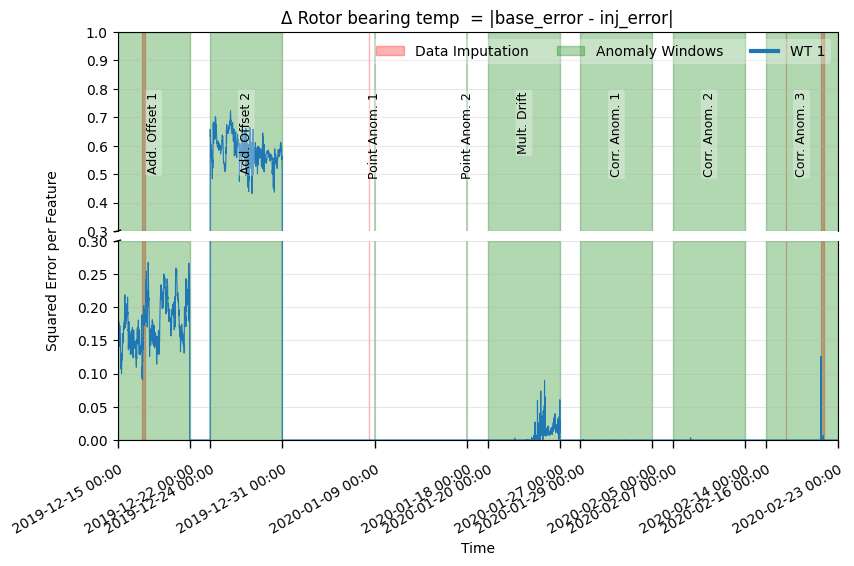

In [27]:

df_diff = ce.Eval_Anom.build_diff_df_for_signal(wt, 
                                                signal=ic.RE_PREFIX+ sigs[0], 
                                                wt_df_raw= df_val_eval,
                                                wt_df_inj= df_test_eval,
                                                ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'))

pp.print_loss(
            df_diff, 
            dpi=500, 
            y_limits=((0,0.3),(0.3,1)), 
            upper_ylim_to_max=False, 
            wt_id=[1],
            title=f"Δ {sigs[0][:-4]} = |base_error - inj_error|" ,
            values=f"{ic.RE_PREFIX}"+sigs[0],
            ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'),
            anomaly_spans=spans_all,
            anom_span_labels=anom_span_labels,
            figsize=(9,6),
            save_filename="part1_add_signal_diff.png",
            show_mean=False,
            impute_label="Data Imputation",
            anom_span_label="Anomaly Windows",
            y_label="Squared Error per Feature"
            )

In [28]:
fp = Path(ic.PATH_IMPUTED).glob(f"WT_ID_{wt}_*")
wt_df_raw = pd.read_csv(next(iter(fp)))

fp2 = Path(ic.PATH_PART1_VAL_SET_INJ_DIR).glob(f"wt_{wt}_*")
wt_df_inj = pd.read_csv(next(iter(fp2)))

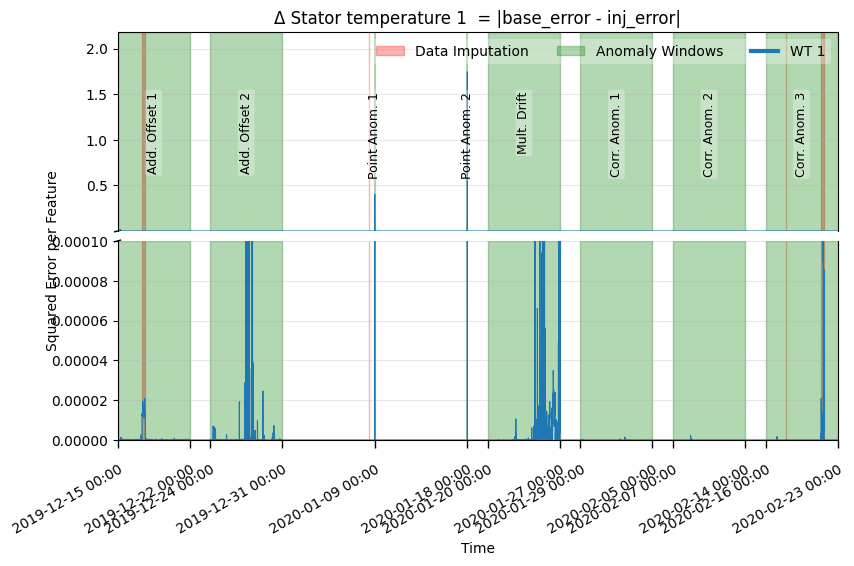

In [29]:
df_diff = ce.Eval_Anom.build_diff_df_for_signal(wt, 
                                                signal=ic.RE_PREFIX+ sigs[1], 
                                                wt_df_raw= df_val_eval,
                                                wt_df_inj= df_test_eval,
                                                ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'))

pp.print_loss(
            df_diff, 
            dpi=500, 
            y_limits=((0,0.0001),(0.0001,5)), 
            wt_id=[1],
            title=f"Δ {sigs[1][:-4]} = |base_error - inj_error|" ,
            values=f"{ic.RE_PREFIX}"+sigs[1],
            ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'),
            anomaly_spans=spans_all,
            anom_span_labels=anom_span_labels,
            figsize=(9,6),
            save_filename="part1_point_signal_diff.png",
            show_mean=False,
            impute_label="Data Imputation",
            anom_span_label="Anomaly Windows",
            y_label="Squared Error per Feature"
            )

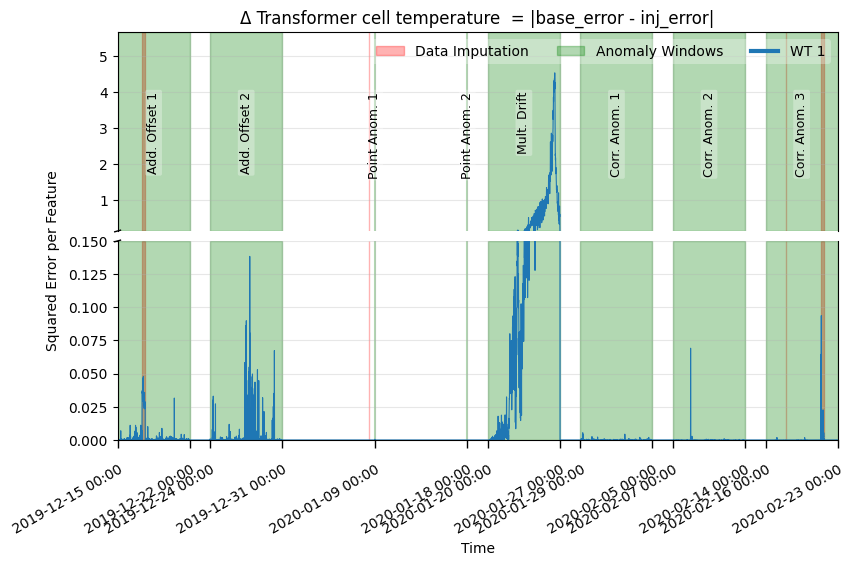

In [30]:
df_diff = ce.Eval_Anom.build_diff_df_for_signal(wt, 
                                                signal=ic.RE_PREFIX+ sigs[2], 
                                                wt_df_raw= df_val_eval,
                                                wt_df_inj= df_test_eval,
                                                ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'))

pp.print_loss(
            df_diff, 
            dpi=500, 
            y_limits=((0,0.15),(0.15,2.5)), 
            wt_id=[1],
            title=f"Δ {sigs[2][:-4]} = |base_error - inj_error|" ,
            values=f"{ic.RE_PREFIX}"+sigs[2],
            ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'),
            anomaly_spans=spans_all,
            anom_span_labels=anom_span_labels,
            figsize=(9,6),
            save_filename="part1_mult_signal_diff.png",
            show_mean=False,
            impute_label="Data Imputation",
            anom_span_label="Anomaly Windows",
            y_label="Squared Error per Feature"
            )

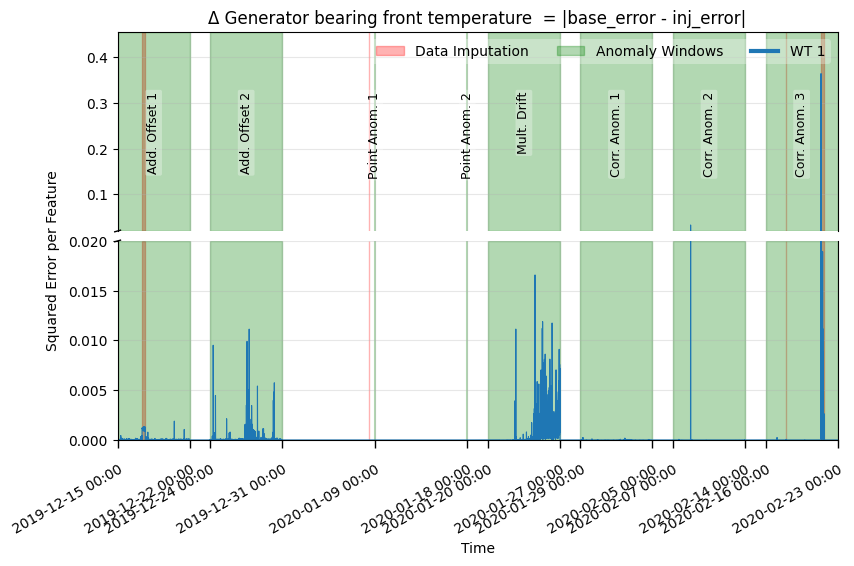

In [31]:

df_diff = ce.Eval_Anom.build_diff_df_for_signal(wt, 
                                                signal=ic.RE_PREFIX+ sigs[3], 
                                                wt_df_raw= df_val_eval,
                                                wt_df_inj= df_test_eval,
                                                ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'))

pp.print_loss(
            df_diff, 
            dpi=500, 
            y_limits=((0,0.02),(0.02,1)), 
            wt_id=[1],
            title=f"Δ {sigs[3][:-4]} = |base_error - inj_error|" ,
            values=f"{ic.RE_PREFIX}"+sigs[3],
            ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'),
            anomaly_spans=spans_all,
            anom_span_labels=anom_span_labels,
            figsize=(9,6),
            save_filename="part1_corr_signal1_diff.png",
            show_mean=False,
            impute_label="Data Imputation",
            anom_span_label="Anomaly Windows",
            y_label="Squared Error per Feature"
            )

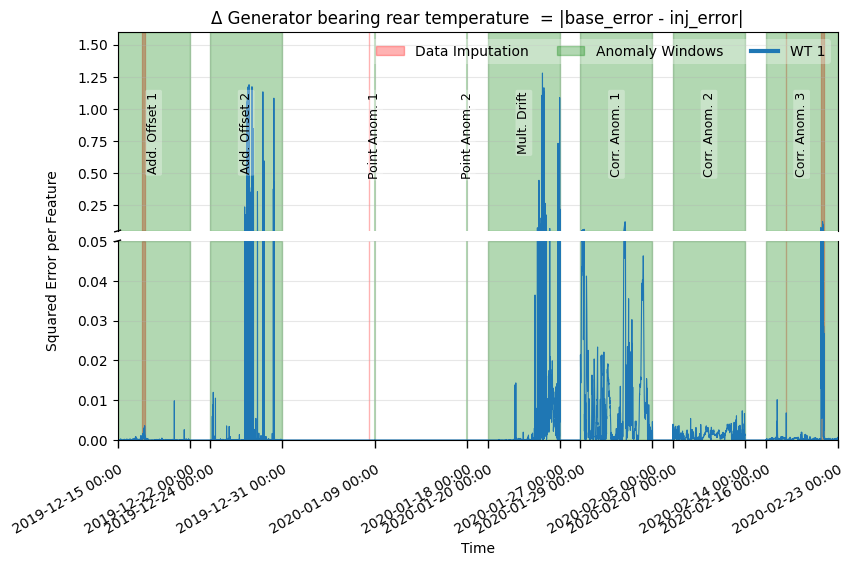

In [32]:

df_diff = ce.Eval_Anom.build_diff_df_for_signal(wt, 
                                                signal=ic.RE_PREFIX+ sigs[4], 
                                                wt_df_raw= df_val_eval,
                                                wt_df_inj= df_test_eval,
                                                ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'))

pp.print_loss(
            df_diff, 
            dpi=500, 
            y_limits=((0,0.05),(0.05,1)),  
            wt_id=[1],
            title=f"Δ {sigs[4][:-4]} = |base_error - inj_error|" ,
            values=f"{ic.RE_PREFIX}"+sigs[4],
            ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'),
            anomaly_spans=spans_all,
            anom_span_labels=anom_span_labels,
            figsize=(9,6),
            save_filename="part1_corr_signal2_diff.png",
            show_mean=False,
            impute_label="Data Imputation",
            anom_span_label="Anomaly Windows",
            y_label="Squared Error per Feature"
            )

In [33]:
window_to_cat = {span: label for span, label in zip(spans_all, anom_span_labels)}
df_test_wt1 = df_test_eval[df_test_eval[ic.WT_ID]==1]
df_best = ce.Eval_Anom.best_signal_in_windows(df_re=df_test_wt1, 
                                              windows= spans_all,
                                              window_to_cat=window_to_cat)
df_best = df_best.replace(r"\bRE_", "", regex=True)
display(df_best)
fmt = {"Max RE": lambda x: f"{x:.2f}"}
ltx2 = df_best.to_latex(index=False, formatters=fmt, escape=False)
with open(ic.PATH_PRINTS/"best_signals.tex", "w", encoding="utf-8") as f:
    f.write(ltx2)

,Start,End,Category,Signal,Max RE
0,2019-12-15,2019-12-22,Add. Offset 1,Hub temperature (°C),0.648808
1,2019-12-24,2019-12-31,Add. Offset 2,Drive train acceleration (mm/ss),2.051867
2,2020-01-09,2020-01-09,Point Anom. 1,Stator temperature 1 (°C),0.402363
3,2020-01-18,2020-01-18,Point Anom. 2,Stator temperature 1 (°C),1.745261
4,2020-01-20,2020-01-27,Mult. Drift,Transformer cell temperature (°C),4.585512
5,2020-01-29,2020-02-05,Corr. Anom. 1,Vane position 1+2 (°),0.336768
6,2020-02-07,2020-02-14,Corr. Anom. 2,Transformer cell temperature (°C),0.879490
7,2020-02-16,2020-02-23,Corr. Anom. 3,Hub temperature (°C),6.617761


In [34]:
sigs2 = ["RE_" + sig for sig in sigs]
print(sigs2)
df_best = ce.Eval_Anom.best_signal_in_windows(df_re=df_test_wt1, 
                                              windows= spans_all,
                                              window_to_cat=window_to_cat,
                                              use_signals=sigs2)
df_best = df_best.replace(r"\bRE_", "", regex=True)
display(df_best)

ltx3 = df_best.to_latex(index=False, formatters=fmt, escape=False)
with open(ic.PATH_PRINTS/"best_signals_filtered.tex", "w", encoding="utf-8") as f:
    f.write(ltx3)

['RE_Rotor bearing temp (°C)', 'RE_Stator temperature 1 (°C)', 'RE_Transformer cell temperature (°C)', 'RE_Generator bearing front temperature (°C)', 'RE_Generator bearing rear temperature (°C)']


,Start,End,Category,Signal,Max RE
0,2019-12-15,2019-12-22,Add. Offset 1,Transformer cell temperature (°C),0.288733
1,2019-12-24,2019-12-31,Add. Offset 2,Generator bearing rear temperature (°C),1.191785
2,2020-01-09,2020-01-09,Point Anom. 1,Stator temperature 1 (°C),0.402363
3,2020-01-18,2020-01-18,Point Anom. 2,Stator temperature 1 (°C),1.745261
4,2020-01-20,2020-01-27,Mult. Drift,Transformer cell temperature (°C),4.585512
5,2020-01-29,2020-02-05,Corr. Anom. 1,Transformer cell temperature (°C),0.146130
6,2020-02-07,2020-02-14,Corr. Anom. 2,Transformer cell temperature (°C),0.879490
7,2020-02-16,2020-02-23,Corr. Anom. 3,Generator bearing front temperature (°C),6.410356


In [35]:
print(anom_span_labels[-3:])

['Corr. Anom. 1', 'Corr. Anom. 2', 'Corr. Anom. 3']


In [36]:
re1 = f"Generator bearing front temperature (°C)"
re2 = f"Generator bearing rear temperature (°C)"


wt_df_inj[ic.TS_COL] = pd.to_datetime(wt_df_inj[ic.TS_COL], errors="raise")
df_wt  = wt_df_inj[wt_df_inj[ic.WT_ID] == wt]

corr_spans = [(pd.to_datetime(s), pd.to_datetime(e)) for (s,e) in spans_all[-3:]]

rows = []
for s,e in corr_spans:
    w = df_wt[(df_wt[ic.TS_COL] >= s) & (df_wt[ic.TS_COL] <= e)]
    x = w[re1].to_numpy(dtype=float)
    y = w[re2].to_numpy(dtype=float)
    rho = np.corrcoef(x,y)[0,1]
    rows.append({"ts start": s, "ts end": e, "ρ": rho})
    
corr_table = pd.DataFrame(rows)
corr_table["ρ"] = corr_table["ρ"].astype(float).round(3)

corr_table.insert(0,"Anomaly", pd.Series(anom_span_labels[-3:], index=corr_table.index))

display(corr_table)

ltx = corr_table.to_latex(index=False, escape=False)
with open(ic.PATH_PRINTS /"p1_corr_inj_test.tex", "w", encoding="utf-8") as f:
    f.write(ltx)

,Anomaly,ts start,ts end,ρ
0,Corr. Anom. 1,2020-01-29,2020-02-05,-0.9
1,Corr. Anom. 2,2020-02-07,2020-02-14,-0.0
2,Corr. Anom. 3,2020-02-16,2020-02-23,0.8


In [37]:
list = zip(anom_span_labels, spans_all)

for l, t in list:
    print(f"l={l}, t={t}")

l=Add. Offset 1, t=(Timestamp('2019-12-15 00:00:00'), Timestamp('2019-12-22 00:00:00'))
l=Add. Offset 2, t=(Timestamp('2019-12-24 00:00:00'), Timestamp('2019-12-31 00:00:00'))
l=Point Anom. 1, t=(Timestamp('2020-01-09 00:00:00'), Timestamp('2020-01-09 00:00:00'))
l=Point Anom. 2, t=(Timestamp('2020-01-18 00:00:00'), Timestamp('2020-01-18 00:00:00'))
l=Mult. Drift, t=(Timestamp('2020-01-20 00:00:00'), Timestamp('2020-01-27 00:00:00'))
l=Corr. Anom. 1, t=(Timestamp('2020-01-29 00:00:00'), Timestamp('2020-02-05 00:00:00'))
l=Corr. Anom. 2, t=(Timestamp('2020-02-07 00:00:00'), Timestamp('2020-02-14 00:00:00'))
l=Corr. Anom. 3, t=(Timestamp('2020-02-16 00:00:00'), Timestamp('2020-02-23 00:00:00'))


In [38]:
display(df_diff.head())

,Date and time,WT_ID,RE_Generator bearing rear temperature (°C)
0,2019-12-15,1,6.099511e-05
1,2019-12-15,2,6.619841e-06
2,2019-12-15,4,5.661277e-07
3,2019-12-15,5,6.770133e-06
4,2019-12-15,6,5.131301e-03


In [39]:
meta_cols = [ic.TS_COL, ic.WT_ID]
re_sigs = [ic.MEAN_LOSS_PER_SAMPLE]+[f"{ic.RE_PREFIX}{sig}" for sig in sigs]
total_cols = meta_cols + re_sigs



base = df_val_eval[total_cols].sort_values(meta_cols).reset_index(drop=True)
inj = df_test_eval[total_cols].sort_values(meta_cols).reset_index(drop=True)



diff = (base[re_sigs] - inj[re_sigs]).abs()
diff_df = pd.concat([inj[meta_cols], diff], axis=1)

display(diff_df.columns)
assert base[meta_cols].equals(inj[meta_cols])

display(diff_df)
display(sigs)

display(diff_df[f"{ic.RE_PREFIX}{sigs[0]}"])

Index(['Date and time', 'WT_ID', 'Mean Loss per Sample',
       'RE_Rotor bearing temp (°C)', 'RE_Stator temperature 1 (°C)',
       'RE_Transformer cell temperature (°C)',
       'RE_Generator bearing front temperature (°C)',
       'RE_Generator bearing rear temperature (°C)'],
      dtype='object')

,Date and time,WT_ID,Mean Loss per Sample,RE_Rotor bearing temp (°C),RE_Stator temperature 1 (°C),RE_Transformer cell temperature (°C),RE_Generator bearing front temperature (°C),RE_Generator bearing rear temperature (°C)
0,2019-11-06 18:40:00,1,0.0,0.0,0.0,0.0,0.0,0.0
1,2019-11-06 18:40:00,2,0.0,0.0,0.0,0.0,0.0,0.0
2,2019-11-06 18:40:00,4,0.0,0.0,0.0,0.0,0.0,0.0
3,2019-11-06 18:40:00,5,0.0,0.0,0.0,0.0,0.0,0.0
4,2019-11-06 18:40:00,6,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
295129,2020-04-01 04:00:00,11,0.0,0.0,0.0,0.0,0.0,0.0
295130,2020-04-01 04:00:00,12,0.0,0.0,0.0,0.0,0.0,0.0
295131,2020-04-01 04:00:00,13,0.0,0.0,0.0,0.0,0.0,0.0
295132,2020-04-01 04:00:00,14,0.0,0.0,0.0,0.0,0.0,0.0


['Rotor bearing temp (°C)',
 'Stator temperature 1 (°C)',
 'Transformer cell temperature (°C)',
 'Generator bearing front temperature (°C)',
 'Generator bearing rear temperature (°C)']

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
295129    0.0
295130    0.0
295131    0.0
295132    0.0
295133    0.0
Name: RE_Rotor bearing temp (°C), Length: 295134, dtype: float64

In [40]:
ratios,mu_b, sigma_b = ce.Report.create_mu_sigma_ratio_table(
    df_base_eval=df_val_eval,
    df_inj_eval=diff_df,
    signals=[ic.MEAN_LOSS_PER_SAMPLE]+sigs,
    anom_spans=spans_all,
    anom_cats=anom_span_labels,
    wt_id=1,
)

In [41]:

display(ratios)
display(sigma_b)
display(mu_b)

,Signal,1. RCM,2. RCM,3. RCM,4. RCM,5. RCM,6. RCM,7. RCM,8. RCM,1. RCSD,2. RCSD,3. RCSD,4. RCSD,5. RCSD,6. RCSD,7. RCSD,8. RCSD
0,MSE,0.388,2.105,1.421,3.230,1.765,0.030,0.004,0.009,0.118,7.126,0.0,0.0,5.168,0.115,0.027,0.027
1,Rotor bearing temp (°C),30.367,86.081,0.007,0.003,0.671,0.002,0.001,0.014,7.772,11.736,0.0,0.0,1.652,0.007,0.008,0.031
2,Stator temperature 1 (°C),0.000,0.004,903.723,1060592.368,0.002,0.000,0.000,0.000,0.001,0.013,0.0,0.0,0.004,0.000,0.000,0.001
3,Transformer cell temperature (°C),0.123,0.338,0.139,0.042,49.744,0.006,0.003,0.009,0.160,0.694,0.0,0.0,59.454,0.017,0.035,0.030
4,Generator bearing front temperature (°C),0.027,0.136,0.127,0.004,0.450,0.003,0.019,0.045,0.028,0.509,0.0,0.0,0.641,0.007,0.174,0.058
5,Generator bearing rear temperature (°C),0.076,15.367,0.570,0.021,11.663,6.706,0.572,0.072,0.259,84.858,0.0,0.0,40.103,6.450,0.101,0.061


,Signal,1. $\hat\sigma_{base}$,2. $\hat\sigma_{base}$,3. $\hat\sigma_{base}$,4. $\hat\sigma_{base}$,5. $\hat\sigma_{base}$,6. $\hat\sigma_{base}$,7. $\hat\sigma_{base}$,8. $\hat\sigma_{base}$
0,MSE,0.010,0.003,0.0,0.0,0.007,0.004,0.012,0.094
1,Rotor bearing temp (°C),0.004,0.004,0.0,0.0,0.006,0.005,0.014,0.165
2,Stator temperature 1 (°C),0.005,0.003,0.0,0.0,0.005,0.003,0.004,0.007
3,Transformer cell temperature (°C),0.043,0.015,0.0,0.0,0.014,0.022,0.062,0.153
4,Generator bearing front temperature (°C),0.009,0.002,0.0,0.0,0.003,0.002,0.006,0.211
5,Generator bearing rear temperature (°C),0.002,0.002,0.0,0.0,0.003,0.003,0.010,0.159


,Signal,1. $\hat\mu_{base}$,2. $\hat\mu_{base}$,3. $\hat\mu_{base}$,4. $\hat\mu_{base}$,5. $\hat\mu_{base}$,6. $\hat\mu_{base}$,7. $\hat\mu_{base}$,8. $\hat\mu_{base}$
0,MSE,0.012,0.009,0.007,0.014,0.012,0.010,0.012,0.021
1,Rotor bearing temp (°C),0.006,0.007,0.016,0.011,0.007,0.007,0.014,0.020
2,Stator temperature 1 (°C),0.002,0.001,0.000,0.000,0.002,0.002,0.002,0.003
3,Transformer cell temperature (°C),0.016,0.009,0.003,0.001,0.010,0.016,0.037,0.048
4,Generator bearing front temperature (°C),0.003,0.001,0.000,0.003,0.002,0.002,0.002,0.014
5,Generator bearing rear temperature (°C),0.001,0.001,0.000,0.000,0.002,0.002,0.002,0.027


In [42]:
ratios = ratios.rename(columns={"Signal": "Target"})
ratios["Target"] = ratios["Target"].replace({
    "MSE": "Δ MSE",
    "Rotor bearing temp (°C)": "Δ Rotor bearing temp (°C)",
    "Stator temperature 1 (°C)": "Δ Stator temperature 1 (°C)",
    "Transformer cell temperature (°C)": "Δ Transformer cell temperature (°C)",
    "Generator bearing front temperature (°C)": "Δ Generator bearing front temperature (°C)",
    "Generator bearing rear temperature (°C)": "Δ Generator bearing rear temperature (°C)",
})
df_ratios1 = ratios.iloc[:, :9].copy()
df_ratios2 = ratios.loc[:,["Target"] + ratios.columns[9:].tolist()].copy()
display(df_ratios1)
display(df_ratios2)

,Target,1. RCM,2. RCM,3. RCM,4. RCM,5. RCM,6. RCM,7. RCM,8. RCM
0,Δ MSE,0.388,2.105,1.421,3.230,1.765,0.030,0.004,0.009
1,Δ Rotor bearing temp (°C),30.367,86.081,0.007,0.003,0.671,0.002,0.001,0.014
2,Δ Stator temperature 1 (°C),0.000,0.004,903.723,1060592.368,0.002,0.000,0.000,0.000
3,Δ Transformer cell temperature (°C),0.123,0.338,0.139,0.042,49.744,0.006,0.003,0.009
4,Δ Generator bearing front temperature (°C),0.027,0.136,0.127,0.004,0.450,0.003,0.019,0.045
5,Δ Generator bearing rear temperature (°C),0.076,15.367,0.570,0.021,11.663,6.706,0.572,0.072


,Target,1. RCSD,2. RCSD,3. RCSD,4. RCSD,5. RCSD,6. RCSD,7. RCSD,8. RCSD
0,Δ MSE,0.118,7.126,0.0,0.0,5.168,0.115,0.027,0.027
1,Δ Rotor bearing temp (°C),7.772,11.736,0.0,0.0,1.652,0.007,0.008,0.031
2,Δ Stator temperature 1 (°C),0.001,0.013,0.0,0.0,0.004,0.000,0.000,0.001
3,Δ Transformer cell temperature (°C),0.160,0.694,0.0,0.0,59.454,0.017,0.035,0.030
4,Δ Generator bearing front temperature (°C),0.028,0.509,0.0,0.0,0.641,0.007,0.174,0.058
5,Δ Generator bearing rear temperature (°C),0.259,84.858,0.0,0.0,40.103,6.450,0.101,0.061


In [43]:
ltx_r = df_ratios1.to_latex(index=False, escape=False,float_format="%.3f")

with open(ic.PATH_PRINTS /"p1_mu_sigma_ratios.tex", "w", encoding="utf-8") as f:
    f.write(ltx_r)

ltx_r2 = df_ratios2.to_latex(index=False, escape=False,float_format="%.3f")

with open(ic.PATH_PRINTS /"p1_mu_sigma_ratios2.tex", "w", encoding="utf-8") as f:
    f.write(ltx_r2)


ltx_s = sigma_b.to_latex(index=False, escape=False,float_format="%.3f")

with open(ic.PATH_PRINTS /"p1_sigmas_b.tex", "w", encoding="utf-8") as f:
    f.write(ltx_s)

ltx_m = mu_b.to_latex(index=False, escape=False,float_format="%.3f")

with open(ic.PATH_PRINTS /"p1_mus_b.tex", "w", encoding="utf-8") as f:
    f.write(ltx_m)

In [44]:
row_to_tex(
    df=ratios,
    fn="p1_diffs_ratio",
)
row_to_tex(
    df=mu_b,
    fn="p1_diffs_mu",
)
row_to_tex(
    df=sigma_b,
    fn="p1_diffs_sigma"
)

C:\Users\admin\AppData\Local\Temp\ipykernel_22936\2636796566.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ptf = (path/f"{fn}_{df.iloc[i][0]}_{i+1}.tex")
C:\Users\admin\AppData\Local\Temp\ipykernel_22936\2636796566.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ptf = (path/f"{fn}_{df.iloc[i][0]}_{i+1}.tex")
C:\Users\admin\AppData\Local\Temp\ipykernel_22936\2636796566.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

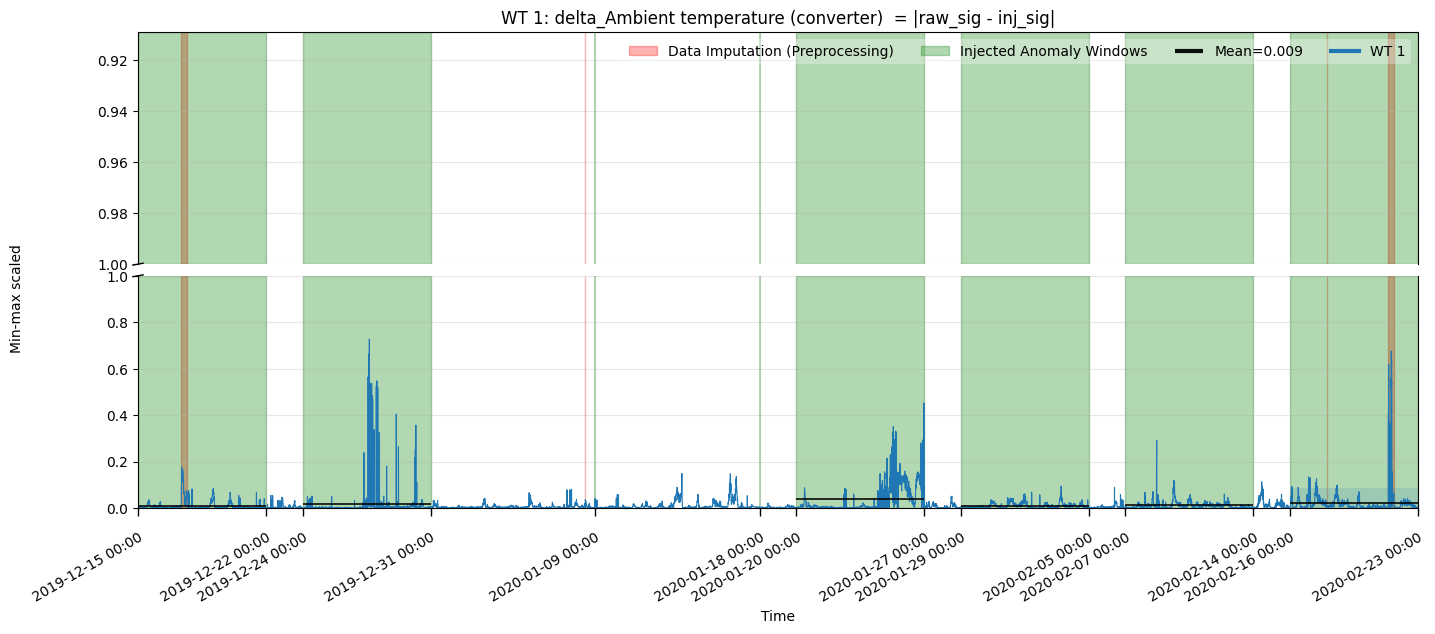

In [45]:
sig = "Ambient temperature (converter) (°C)"

pp.print_loss(
            df_test_eval,
            #df_val_eval, 
            dpi=500, 
            y_limits=((0,1),(1,20)), 
            wt_id=[1],
            title=f"WT {wt}: delta_{sig[:-4]} = |raw_sig - inj_sig|" ,
            values=f"{ic.RE_PREFIX}{sig}",
            ts_range=(ic.START_ANOM, '2020-02-23 00:00:00'),
            anomaly_spans=spans_all,
            y_label="Min-max scaled"
            )

In [46]:
display(spans_all)

[(Timestamp('2019-12-15 00:00:00'), Timestamp('2019-12-22 00:00:00')),
 (Timestamp('2019-12-24 00:00:00'), Timestamp('2019-12-31 00:00:00')),
 (Timestamp('2020-01-09 00:00:00'), Timestamp('2020-01-09 00:00:00')),
 (Timestamp('2020-01-18 00:00:00'), Timestamp('2020-01-18 00:00:00')),
 (Timestamp('2020-01-20 00:00:00'), Timestamp('2020-01-27 00:00:00')),
 (Timestamp('2020-01-29 00:00:00'), Timestamp('2020-02-05 00:00:00')),
 (Timestamp('2020-02-07 00:00:00'), Timestamp('2020-02-14 00:00:00')),
 (Timestamp('2020-02-16 00:00:00'), Timestamp('2020-02-23 00:00:00'))]

In [47]:

fw= spans_all[0]
print(fw)
df_filtered = df_test_eval[df_test_eval[ic.WT_ID] == wt]
df_filtered = df_filtered[(df_filtered[ic.TS_COL]>= fw[0]) & (df_filtered[ic.TS_COL] <= fw[1])]

df_filtered = df_filtered["RE_Hub temperature (°C)"].max()
display(df_filtered)


(Timestamp('2019-12-15 00:00:00'), Timestamp('2019-12-22 00:00:00'))


0.6488078236579895

In [48]:
display(spans_all)

[(Timestamp('2019-12-15 00:00:00'), Timestamp('2019-12-22 00:00:00')),
 (Timestamp('2019-12-24 00:00:00'), Timestamp('2019-12-31 00:00:00')),
 (Timestamp('2020-01-09 00:00:00'), Timestamp('2020-01-09 00:00:00')),
 (Timestamp('2020-01-18 00:00:00'), Timestamp('2020-01-18 00:00:00')),
 (Timestamp('2020-01-20 00:00:00'), Timestamp('2020-01-27 00:00:00')),
 (Timestamp('2020-01-29 00:00:00'), Timestamp('2020-02-05 00:00:00')),
 (Timestamp('2020-02-07 00:00:00'), Timestamp('2020-02-14 00:00:00')),
 (Timestamp('2020-02-16 00:00:00'), Timestamp('2020-02-23 00:00:00'))]

In [49]:
meta_cols = [ic.TS_COL, ic.WT_ID]
re_sigs = [ic.MEAN_LOSS_PER_SAMPLE]+[f"{ic.RE_PREFIX}{sig}" for sig in hfn.load_feature_order()]
total_cols = meta_cols + re_sigs



base = df_val_eval[total_cols].sort_values(meta_cols).reset_index(drop=True)
inj = df_test_eval[total_cols].sort_values(meta_cols).reset_index(drop=True)



diff = (base[re_sigs] - inj[re_sigs]).abs()
diff_all_sigs = pd.concat([inj[meta_cols], diff], axis=1)

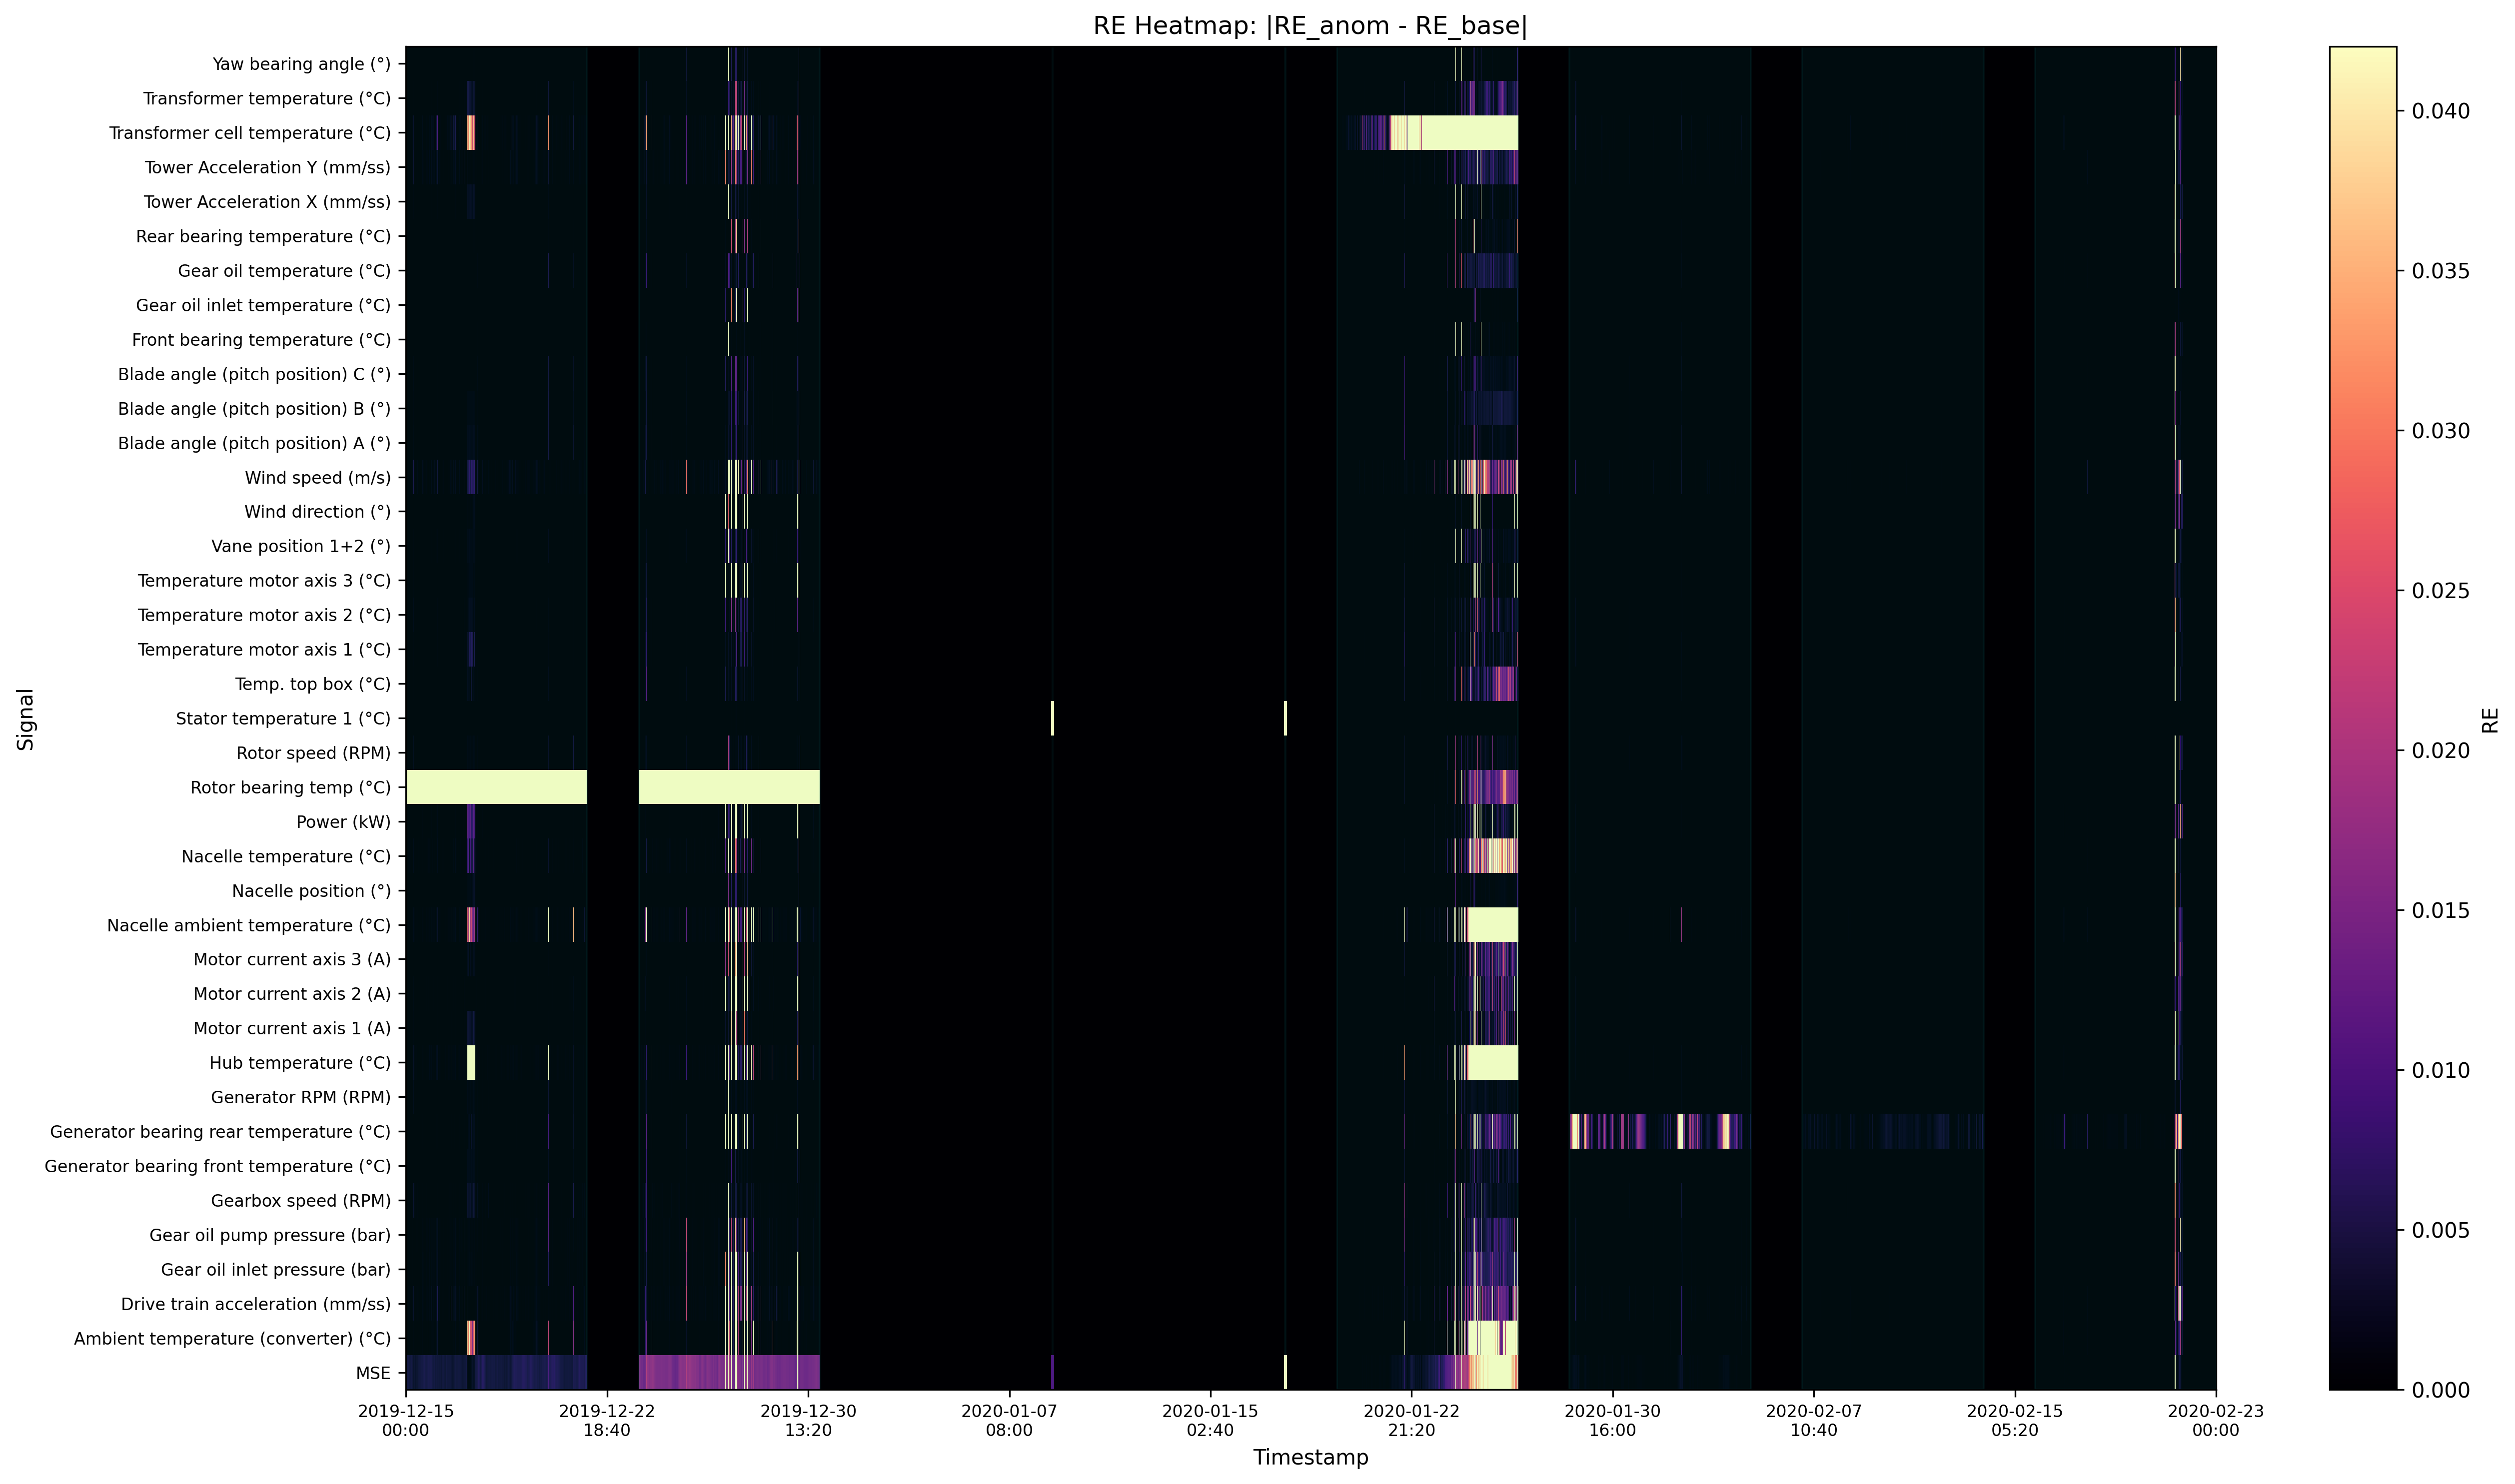

In [ ]:
pp.plot_heatmap_RE(diff_all_sigs,
                   windows=spans_all,
                   point_width=8,
                   point_signal="Stator temperature 1 (°C)",
                   cmap="magma",
                   use_lognorm=False,
                   use_manual_color_scale=True,
                   vmax=0.002,
                   title="RE Heatmap: |RE_anom - RE_base|")